# 31_01 — Simulación y preprocesamiento · Escenario T1 (núcleo cuadrático + tendencia cuadrática)

Es el **Escenario 1** del anexo —FAR(1) lineal y gaussiano— con **dos** cambios, ambos cuadráticos y ambos declarados en la celda `[CONFIG]` de §2.1:

1. el **núcleo del operador** deja de ser gaussiano y pasa a ser un polinomio de grado 2 en $(\tau-s)$ —Epanechnikov—, y
2. una **tendencia determinista cuadrática** se superpone al nivel de la curva.

El proceso sigue siendo **lineal en $Y_{t-1}$**: lo que cambia es la *forma* del núcleo, no el orden del operador. La ley condicional sigue siendo gaussiana y unimodal, de modo que las referencias lineales siguen correctamente especificadas en la media —igual que en el Escenario 1— y esta corrida no pretende romper eso:

$$X_t(\tau) = \mu(\tau) + \int_0^1 \psi(\tau,s)\,(X_{t-1}(s)-\mu(s))\,ds + \varepsilon_t(\tau) + b(t)\,g(\tau),$$

$$\psi(\tau,s) = c\left[1-\Big(\tfrac{\tau-s}{h}\Big)^{2}\right]_{+},\qquad b(t) = \text{deriva}\cdot u_t^2,\quad u_t=\tfrac{t-1}{T-1},$$

con $c$ calibrada para que $\|\Psi\|_{HS}$ alcance el valor objetivo, exactamente como en `matriz_operador_ar`.

Todo lo demás —esquema de observación, $\|\Psi\|_{HS}=0.7$, innovación, priors, `mcmc_config`— es idéntico a la corrida 30. El único notebook que difiere de la corrida 30 es **éste**; `31_03`, `31_04` y `31_05` son réplicas suyas salvo el `BASENAME`.

La forma cuadrática es el **caso adverso**: con $T_0=0.7T$ deja $b(T_0)=0.49\cdot$deriva, o sea que la mitad del desplazamiento ocurre **dentro del bloque de prueba**, y el centrado del FPCA y del estandarizador —ajustados sólo con el entrenamiento— pierden vigencia en el test. Parte del error de prueba será por tanto de *vigencia del centrado* y no de capacidad predictiva: hay que declararlo al reportar.

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: *este notebook** genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR
- 02: psbp_fd_iteracion.m muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento 
- 03, 04, 05: `31_03_convergencia` / `31_04_evaluacion` / `31_05_comparacion` 

Nota: Aca solo se simulan los objetos para entrenar en el  muestreador y para ajsutar el FAR en R. 

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento. Todo lo demás se deriva de ellas.

## 1. Imports y rutas

In [1]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenario1, resumen_escenario_1, guardar_escenario,
    perfil_tendencia, forma_tendencia_lineal_en_tau,
    # Piezas de sim_comun con que se arma el generador de nucleo cuadratico
    SalidaSimulacion, grilla_regular, pesos_trapezoidales, evaluar_media,
    matriz_operador_ar, matriz_covarianza_innovacion, factor_cholesky,
    simular_trayectoria_far1, semillas_replicas, aplicar_ruido_observacion,
    norma_hilbert_schmidt,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario_T"
ESCENARIO_ID = 1      # Algoritmo k del anexo
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json
M_FPCA_LIST = (1, 2, 3)

LIMPIAR_DIRECTORIOS = True

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_T_1_r01
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3]
   M=1  ->  escenario_T_1_r01_m01
   M=2  ->  escenario_T_1_r01_m02
   M=3  ->  escenario_T_1_r01_m03


In [3]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_T_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_T_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_T_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_T_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_T_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_T_1_r01_m01
M=2  (escenario_T_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_T_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_T_1_r01_m02
  predict      -> C:\Users\56jua\Desktop\

## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

`hs_norm` (norma Hilbert-Schmidt; $<1$ garantiza estacionariedad de la
componente dinámica), `sigma_eps` y `ell` (escala y suavidad de la innovación
funcional) **no se tocan**: son los de la corrida 30, y ésa es la condición para
que la comparación aísle lo que sí cambia.

#### El núcleo del operador

`matriz_operador_ar` usa $\psi(\tau,s)=c\exp\{-(\tau-s)^2/2\gamma^2\}$. Aquí se
sustituye por un **polinomio de grado 2 en $(\tau-s)$**, el núcleo de
Epanechnikov, con la misma calibración de $c$ contra $\|\Psi\|_{HS}$ y la misma
cuadratura trapezoidal, de modo que la única diferencia es la forma:

| | |
|---|---|
| `H_NUCLEO` | semiancho del soporte del núcleo. **No es el `gamma` gaussiano**: la gaussiana de desviación $\gamma$ y la Epanechnikov de semiancho $h$ tienen la misma desviación cuando $h=\sqrt5\,\gamma$, y ése es el valor por defecto ($\gamma=0.3\Rightarrow h\approx0.6708$). Igualar el **alcance** es lo que hace que la comparación con la corrida 30 mida la *forma* del núcleo y no su anchura. |
| `TRUNCAR_NUCLEO` | `True` recorta a cero fuera del soporte (Epanechnikov propiamente dicho, no negativo, **soporte compacto**: la influencia de $X_{t-1}(s)$ sobre $X_t(\tau)$ se anula exactamente para $\lvert\tau-s\rvert>h$, cosa que la gaussiana nunca hace). `False` deja el polinomio correr y el núcleo **cambia de signo** en las colas, que es un operador cualitativamente distinto y no una variante cosmética. |

La recursión sigue siendo **lineal**: $\Psi$ es un operador integral y sólo se
cambió su núcleo. Nada de lo que sigue —FPCA, datasets AR, contrato con
MATLAB— se entera.

#### La tendencia

| | |
|---|---|
| `DERIVA` | desplazamiento **total** acumulado entre $t=1$ y $t=T$, en unidades de $X$. Con $\mathrm{sd}(X)\approx 1.2$, el valor 3.0 son ~2.5 desviaciones: grande a propósito, porque con $R=1$ el efecto debe ser inequívoco. |
| `FORMA_TENDENCIA` | `"cuadratica"`, normalizada de modo que $b(1)=0$ y $b(T)=$ `DERIVA` (misma parametrización que `perfil_tendencia` de `sim_escenario_T`, para que esta corrida sea comparable con esa familia). |
| `INCLINACION` | $c$ de $g(\tau)=1+c(\tau-\tfrac12)$. Cero es **nivel puro**: la deriva es idéntica en todo el dominio y no inclina la curva, de modo que carga sobre la dirección casi constante del espectro FPCA. |

**El proceso deja de ser estacionario** por construcción, y el diagnóstico lo
reporta como tal en vez de simular que lo verifica.

In [4]:
# ── Parámetros fijos del estudio (comunes a los 6 escenarios) ────────────────
L_GRILLA   = 100     # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 800    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25    # desviación del ruido de medición

def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau). Con nombre para que quede legible en el JSON.

    Es la media del Cuadro tab:ane_esquema del anexo, común a los seis
    escenarios. La corrida 11 usó 5 + 2 sin(2 pi tau): el FPCA centra con la
    media empírica y el efecto práctico es menor, pero la divergencia rompía
    la comparabilidad declarada y por eso esta corrida la corrige.
    """
    return np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario1(
    # Esquema de observación
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 500,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Operador autorregresivo
    gamma     = 0.3,
    hs_norm   = 0.7,
    # Innovación funcional
    sigma_eps = 1.0,
    ell       = 0.5,
)

# ── [CONFIG] Núcleo CUADRÁTICO del operador ──────────────────────────────
# El gaussiano de sim_comun se sustituye por un polinomio de grado 2. Vive aquí
# y no en el paquete a propósito: es propio de esta corrida y `matriz_operador_ar`
# no debe cambiar de significado para las demás.
H_NUCLEO       = float(np.sqrt(5.0)) * 0.30   # semiancho; sqrt(5)*gamma iguala la sd de la gaussiana
TRUNCAR_NUCLEO = True                         # True = Epanechnikov (soporte compacto, no negativo)


def nucleo_cuadratico(tau, h, truncado=True):
    """psi(tau, s) / c = [1 - ((tau - s)/h)^2]_+   —  polinomio de grado 2.

    Es la contraparte cuadrática exacta del gaussiano de `matriz_operador_ar`:
    mismo papel (núcleo de suavizamiento con alcance `h` sobre la distancia
    |tau - s|), distinta forma. Con `truncado=False` el polinomio no se recorta
    y el núcleo se vuelve NEGATIVO para |tau - s| > h: el operador deja de ser
    positivo y la curva rezagada contribuye con signo opuesto en las colas.
    """
    u2 = ((np.asarray(tau, float)[:, None]
           - np.asarray(tau, float)[None, :]) / float(h)) ** 2
    k = 1.0 - u2
    return np.maximum(k, 0.0) if truncado else k


def matriz_operador_ar_cuadratico(tau, h, hs_norm, truncado=True):
    """Psi (L, L) con núcleo cuadrático, calibrado a ||Psi||_HS = hs_norm.

    Copia línea a línea la mecánica de `matriz_operador_ar` —cuadratura
    trapezoidal en s, constante c calibrada contra la norma HS discretizada—
    y sólo cambia el núcleo. Que la calibración sea la misma es lo que permite
    contrastar esta corrida con la 30 a igual persistencia nominal.
    """
    if h <= 0:
        raise ValueError("h debe ser positivo.")
    if hs_norm <= 0:
        raise ValueError("hs_norm debe ser positivo.")
    w = pesos_trapezoidales(tau)
    nucleo = nucleo_cuadratico(tau, h, truncado)
    hs_nucleo = float(np.sqrt(np.sum((w[:, None] * w[None, :]) * nucleo ** 2)))
    if hs_nucleo <= 0:
        raise RuntimeError(
            "El núcleo cuadrático discretizado resultó idénticamente nulo: h es "
            "menor que el paso de la grilla.")
    return ((hs_norm / hs_nucleo) * nucleo) * w[None, :]


# ── [CONFIG] Tendencia determinista superpuesta ─────────────────────────
# Es lo ÚNICO que distingue esta corrida de la 30. Se aplica DESPUÉS de generar
# el Algoritmo 1, de modo que la componente dinámica es bit-idéntica a la de
# aquélla con la misma semilla y la comparación aísla el efecto de la tendencia.
DERIVA          = 3.0            # desplazamiento total entre t=1 y t=T, en unidades de X
FORMA_TENDENCIA = "cuadratica"   # b(t)/deriva = u^2 con u = (t-1)/(T-1)
INCLINACION     = 0.0            # g(tau) = 1 + c (tau - 1/2); cero = nivel puro

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<12}: {v}")
print(f"\n  {'deriva':<12}: {DERIVA}")
print(f"  {'forma':<12}: {FORMA_TENDENCIA}")
print(f"  {'inclinacion':<12}: {INCLINACION}")
print(f"\n  {'h_nucleo':<12}: {H_NUCLEO:.4f}   (= sqrt(5) x gamma={SIM_CFG.gamma}, misma sd que el gaussiano)")
print(f"  {'truncado':<12}: {TRUNCAR_NUCLEO}")

  L           : 100
  T           : 800
  burn_in     : 500
  sigma_obs   : 0.25
  R           : 1
  seed        : 41232
  media_fn    : media_senoidal
  jitter      : 1e-10
  gamma       : 0.3
  hs_norm     : 0.7
  sigma_eps   : 1.0
  ell         : 0.5

  deriva      : 3.0
  forma       : cuadratica
  inclinacion : 0.0

  h_nucleo    : 0.6708   (= sqrt(5) x gamma=0.3, misma sd que el gaussiano)
  truncado    : True


### 2.2 El núcleo, dibujado

Lo que hay que mirar es el **perfil**, no el mapa: los dos núcleos tienen la
misma norma HS y (por la elección de $h=\sqrt5\gamma$) la misma desviación, de
modo que difieren sólo en cómo reparten esa masa. El cuadrático es **más plano
en el centro y se corta en seco** en $\lvert\tau-s\rvert=h$; el gaussiano decae
suave y nunca llega a cero.

`hs_error` y `radio_espectral` cierran la verificación: la calibración tiene que
dar $\|\Psi\|_{HS}$ exacto, y el radio espectral —que acota inferiormente la
norma— dice cuánta de esa norma se traduce en persistencia efectiva.

  cuadrático (esta corrida)  ||Psi||_HS = 0.700000  (error 0.00e+00)   radio espectral = 0.6426
  gaussiano (corrida 30)     ||Psi||_HS = 0.700000  (error 0.00e+00)   radio espectral = 0.6215


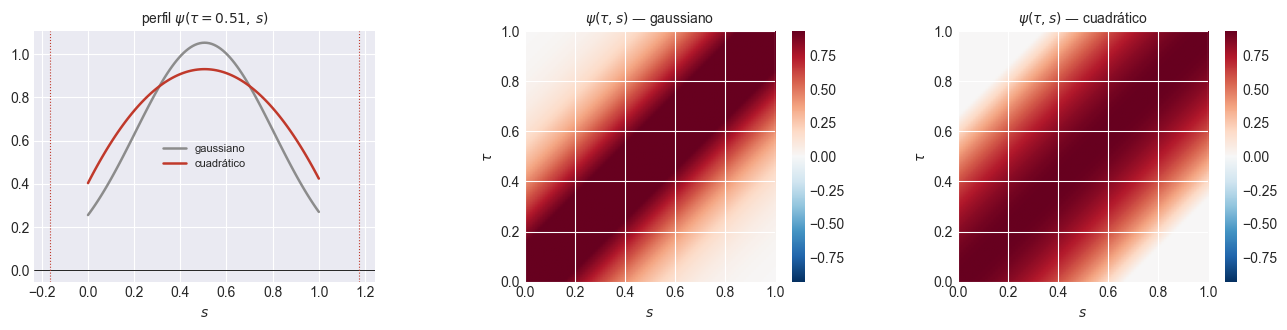

In [5]:
_tau  = grilla_regular(SIM_CFG.L)
_w    = pesos_trapezoidales(_tau)
PSI_Q = matriz_operador_ar_cuadratico(_tau, H_NUCLEO, SIM_CFG.hs_norm, TRUNCAR_NUCLEO)
PSI_G = matriz_operador_ar(_tau, SIM_CFG.gamma, SIM_CFG.hs_norm)   # el de la corrida 30

for _nom, _P in [("cuadrático (esta corrida)", PSI_Q), ("gaussiano (corrida 30)", PSI_G)]:
    _hs  = norma_hilbert_schmidt(_P, _w)
    _rad = float(np.max(np.abs(np.linalg.eigvals(_P))))
    print(f"  {_nom:26s} ||Psi||_HS = {_hs:.6f}  (error {abs(_hs - SIM_CFG.hs_norm):.2e})"
          f"   radio espectral = {_rad:.4f}")

assert abs(norma_hilbert_schmidt(PSI_Q, _w) - SIM_CFG.hs_norm) < 1e-10, (
    "La calibración del núcleo cuadrático no alcanza el hs_norm objetivo.")

_mid = SIM_CFG.L // 2
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(_tau, PSI_G[_mid] / _w, color="0.55", lw=1.8, label="gaussiano")
axes[0].plot(_tau, PSI_Q[_mid] / _w, color="#c0392b", lw=1.8, label="cuadrático")
axes[0].axhline(0, color="k", lw=0.6)
axes[0].axvline(_tau[_mid] - H_NUCLEO, color="#c0392b", lw=0.8, ls=":")
axes[0].axvline(_tau[_mid] + H_NUCLEO, color="#c0392b", lw=0.8, ls=":")
axes[0].set_title(rf"perfil $\psi(\tau={_tau[_mid]:.2f},\,s)$", fontsize=10)
axes[0].set_xlabel("$s$"); axes[0].legend(fontsize=8)
for _ax, (_nom, _P) in zip(axes[1:], [("gaussiano", PSI_G), ("cuadrático", PSI_Q)]):
    _im = _ax.imshow(_P / _w, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu_r",
                     vmin=-np.abs(PSI_Q / _w).max(), vmax=np.abs(PSI_Q / _w).max())
    _ax.set_title(rf"$\psi(\tau, s)$ — {_nom}", fontsize=10)
    _ax.set_xlabel("$s$"); _ax.set_ylabel(r"$\tau$")
    fig.colorbar(_im, ax=_ax, fraction=0.046)
fig.tight_layout()
replicar_figura("00_nucleo_operador.png", PATHS_POR_M, fig=fig)
plt.show()

### 2.3 Generación

In [6]:
def generar_con_nucleo(cfg, Psi):
    """`generar_escenario_1` con el operador entregado desde fuera.

    Reproduce el generador del Algoritmo 1 —misma derivación de semillas por
    réplica, misma innovación, mismo ruido de medición— y sólo se salta la
    construcción interna de `Psi`. El diagnóstico sigue siendo el de
    `resumen_escenario_1`, que verifica la norma HS EFECTIVA del operador
    recibido: si la calibración del núcleo cuadrático estuviera mal, se vería
    ahí y no habría que confiar en este notebook.
    """
    cfg.validar()
    tau_ = grilla_regular(cfg.L)
    w_   = pesos_trapezoidales(tau_)
    mu_  = evaluar_media(cfg.media_fn, tau_)
    K_   = matriz_covarianza_innovacion(tau_, cfg.sigma_eps, cfg.ell)
    ch_  = factor_cholesky(K_, cfg.jitter)
    hijas, registro = semillas_replicas(cfg.seed, cfg.R)

    curvas_ = np.empty((cfg.R, cfg.T, cfg.L))
    obs_    = np.empty((cfg.R, cfg.T, cfg.L))
    for r, semilla in enumerate(hijas):
        rng = np.random.default_rng(semilla)
        c_r = simular_trayectoria_far1(Psi, ch_, mu_, cfg.T, cfg.burn_in, rng)
        curvas_[r] = c_r
        obs_[r]    = aplicar_ruido_observacion(c_r, cfg.sigma_obs, rng)

    out = SalidaSimulacion(
        observaciones=obs_, curvas=curvas_, grilla=tau_, media=mu_,
        semillas=registro, config=cfg,
        internos={"operador": Psi, "cov_innovacion": K_, "pesos_cuadratura": w_},
    )
    out.diagnostico = resumen_escenario_1(out)
    return out


PSI_Q = matriz_operador_ar_cuadratico(
    grilla_regular(SIM_CFG.L), H_NUCLEO, SIM_CFG.hs_norm, TRUNCAR_NUCLEO)
salida = generar_con_nucleo(SIM_CFG, PSI_Q)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
grilla = salida.grilla
T, G   = X_raw.shape

# ── Tendencia determinista ───────────────────────────────────────────
# Se suma a las DOS matrices: es parte de la curva verdadera, no del ruido de
# medición. Si sólo se sumara a la observada, el "error" del modelo incluiría la
# tendencia entera y la evaluación dejaría de medir lo que dice medir.
t_idx  = np.arange(1, T + 1)
b_t    = DERIVA * perfil_tendencia(t_idx, T, FORMA_TENDENCIA)          # (T,)
g_tau  = forma_tendencia_lineal_en_tau(INCLINACION)(grilla)            # (G,)
TEND   = np.outer(b_t, g_tau)                                          # (T, G)

X_raw  = X_raw  + TEND
X_true = X_true + TEND
# El .npz de §2.5 se escribe desde `salida`: hay que actualizarla también, o el
# artefacto en disco no coincidiría con lo que este notebook usa aguas abajo.
salida.observaciones[REPLICA_IDX]  = X_raw
salida.curvas[REPLICA_IDX]         = X_true
salida.internos["tendencia"]       = TEND
salida.internos["tendencia_b_t"]   = b_t
salida.internos["tendencia_g_tau"] = g_tau

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador (núcleo cuadrático, componente dinámica SIN tendencia):")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")

Observadas (800, 100) · verdaderas (800, 100) · grilla (100,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2501   (nominal 0.25)

Control de calidad del generador (núcleo cuadrático, componente dinámica SIN tendencia):
  n_replicas                       = 1
  n_curvas                         = 800
  n_puntos_grilla                  = 100
  todo_finito                      = True
  media_empirica_global            = 0.07812558979345816
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.5158590250644486
  var_puntual_min                  = 1.2018012504450721
  var_puntual_max                  = 1.728302675386513
  acf1_media                       = 0.5721544751801936
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = 24.253744401031177
  hs_norm_objetivo                 = 0.7
  hs_norm_efectiva                 = 0.7
  hs_norm_error_absoluto           = 0.0
  radio_espectral_operador         = 0.6425676307024757
  estacionaried

### 2.4 Diagnóstico de la tendencia

Tres cifras deciden si la tendencia sirve, y se verifican con `assert` para que
el notebook falle en vez de callar:

- **`deriva_neta_en_sd`** — el desplazamiento total en desviaciones de la
  componente estable. Por debajo de 1 la tendencia no se ve en el histórico y el
  escenario no prueba nada.
- **`curvatura_en_sd`** — máxima distancia entre $b(t)$ y su propia recta de
  mínimos cuadrados. La cuadrática es de las formas *menos* curvas del catálogo
  ($\text{deriva}/4$): por debajo de ~0.5 sd la tendencia **se lee como lineal**,
  y entonces lo que la distingue de una tendencia lineal no es su aspecto sino el
  desfase entre bloques.
- **`desfase_en_sd`** — diferencia entre el nivel medio de $b(t)$ en test y en
  entrenamiento. Es exactamente lo que invalida el centrado del FPCA.

`acf1` se reporta **en bruto y destendenciado**: la tendencia por sí sola induce
persistencia, de modo que un VAR sobre scores parecerá excelente sin haber
aprendido nada de la dinámica. La cifra que habla de la dinámica es la segunda.

  forma                        = cuadratica
  deriva                       = 3.0
  inclinacion                  = 0.0
  sd_componente_estable        = 1.3996190825349362
  b_en_T0                      = 1.4684234517176509
  b_en_T0_sobre_deriva         = 0.4894744839058836
  deriva_neta_en_sd            = 2.1434403384716045
  curvatura_en_sd              = 0.3567929474552235
  desfase_en_sd                = 1.2163154296703482
  acf1_nivel_bruto             = 0.7858242553627401
  acf1_nivel_destendenciado    = 0.6514416969302185
  estacionario                 = False


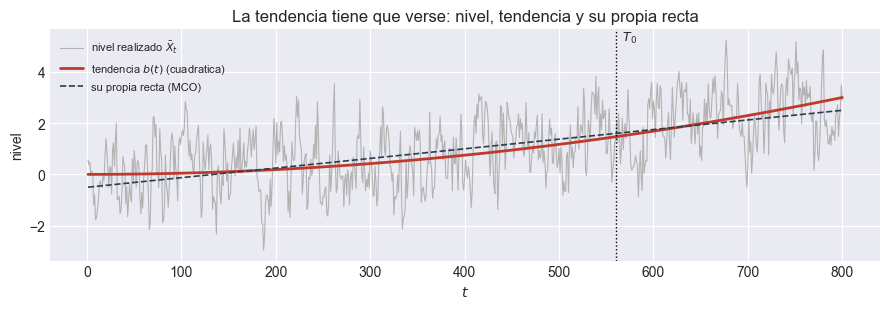

In [7]:
_T0_ref  = int(np.floor(PROP_TRAIN * T))
_sd_est  = float(np.std(X_true - TEND))                     # componente estable
_recta   = np.polyval(np.polyfit(t_idx, b_t, 1), t_idx)
_gbar    = float(g_tau.mean())
_niv     = X_true.mean(axis=1)
_niv_dt  = _niv - b_t * _gbar

def _acf1(x):
    x = np.asarray(x, float) - np.mean(x)
    return float(np.sum(x[1:] * x[:-1]) / np.sum(x ** 2))

DIAG_TENDENCIA = {
    "forma":                 FORMA_TENDENCIA,
    "deriva":                float(DERIVA),
    "inclinacion":           float(INCLINACION),
    "sd_componente_estable": _sd_est,
    "b_en_T0":               float(b_t[_T0_ref - 1]),
    "b_en_T0_sobre_deriva":  float(b_t[_T0_ref - 1] / DERIVA),
    "deriva_neta_en_sd":     float((b_t[-1] - b_t[0]) * _gbar / _sd_est),
    "curvatura_en_sd":       float(np.max(np.abs(b_t - _recta)) * _gbar / _sd_est),
    "desfase_en_sd":         float((b_t[_T0_ref:].mean() - b_t[:_T0_ref].mean())
                                   * _gbar / _sd_est),
    "acf1_nivel_bruto":          _acf1(_niv),
    "acf1_nivel_destendenciado": _acf1(_niv_dt),
    "estacionario":          False,
}
for k, v in DIAG_TENDENCIA.items():
    print(f"  {k:28s} = {v}")

assert DIAG_TENDENCIA["deriva_neta_en_sd"] > 1.0, (
    "La tendencia no supera una desviación de la componente estable: no se vería "
    "en el histórico. Suba DERIVA.")
assert DIAG_TENDENCIA["desfase_en_sd"] > 0.5, (
    "El desfase entre bloques es pequeño: el centrado del entrenamiento seguiría "
    "siendo válido en el test y el escenario no probaría nada.")
assert abs(b_t[0]) < 1e-12 and abs(b_t[-1] - DERIVA) < 1e-9, (
    "perfil_tendencia debe estar normalizado a b(1)=0, b(T)=deriva.")

_mu_bar = float(np.mean(salida.media))
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_idx, _niv, color="0.7", lw=0.8, label=r"nivel realizado $\bar{X}_t$")
ax.plot(t_idx, b_t * _gbar + _mu_bar, color="#c0392b", lw=2.0,
        label=f"tendencia $b(t)$ ({FORMA_TENDENCIA})")
ax.plot(t_idx, _recta * _gbar + _mu_bar, "--", color="#2c3e50", lw=1.2,
        label="su propia recta (MCO)")
ax.axvline(_T0_ref + 0.5, color="k", lw=1.0, ls=":")
ax.text(_T0_ref + 0.5, ax.get_ylim()[1], "  $T_0$", va="top", fontsize=9)
ax.set_xlabel("$t$"); ax.set_ylabel("nivel")
ax.set_title("La tendencia tiene que verse: nivel, tendencia y su propia recta")
ax.legend(fontsize=8); fig.tight_layout()
replicar_figura("05_tendencia_nivel.png", PATHS_POR_M, fig=fig)
plt.show()

In [8]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "tendencia":     DIAG_TENDENCIA,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_T_1_r01_m01\escenario_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_T_1_r01_m02\escenario_1.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_T_1_r01_m03\escenario_1.npz


### 2.5 Visualización de los datos

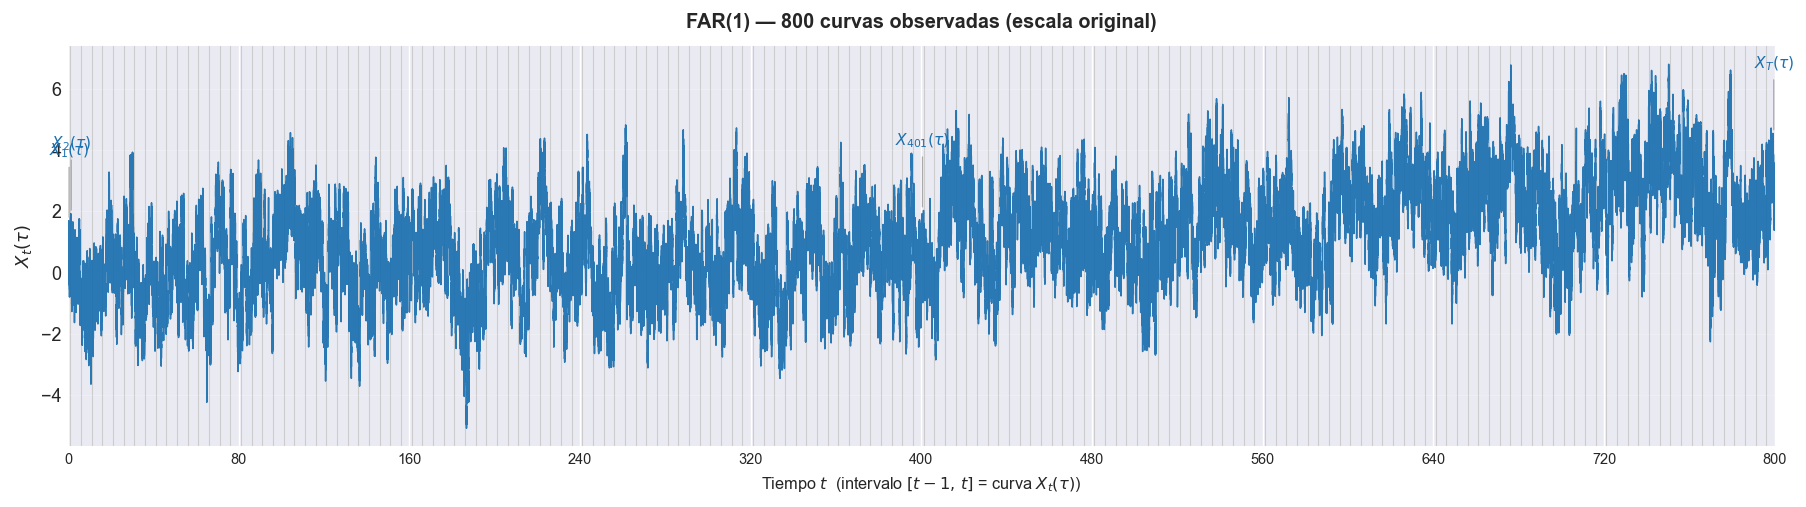

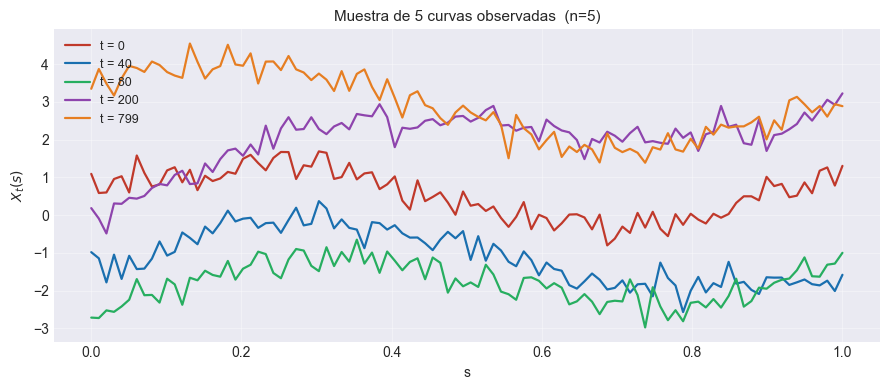

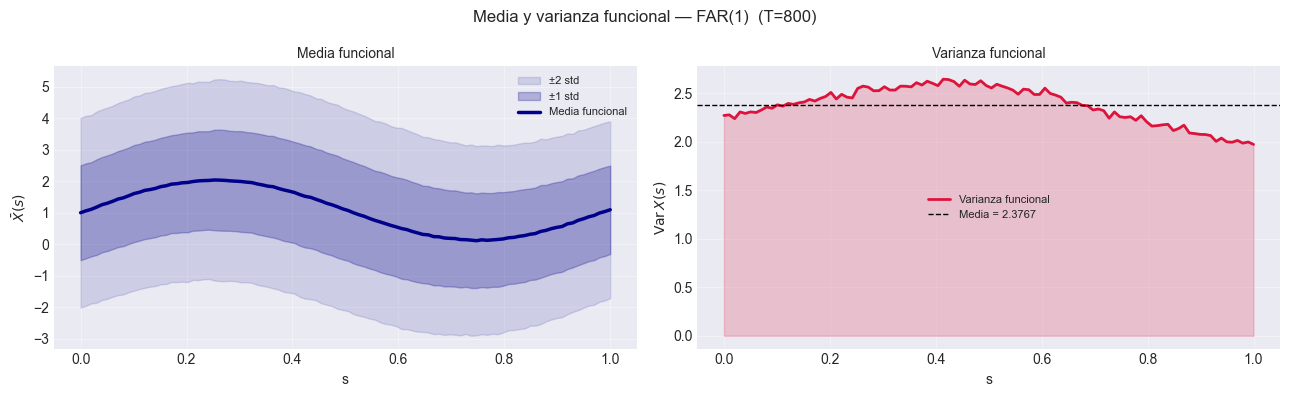

In [9]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — FAR(1)")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

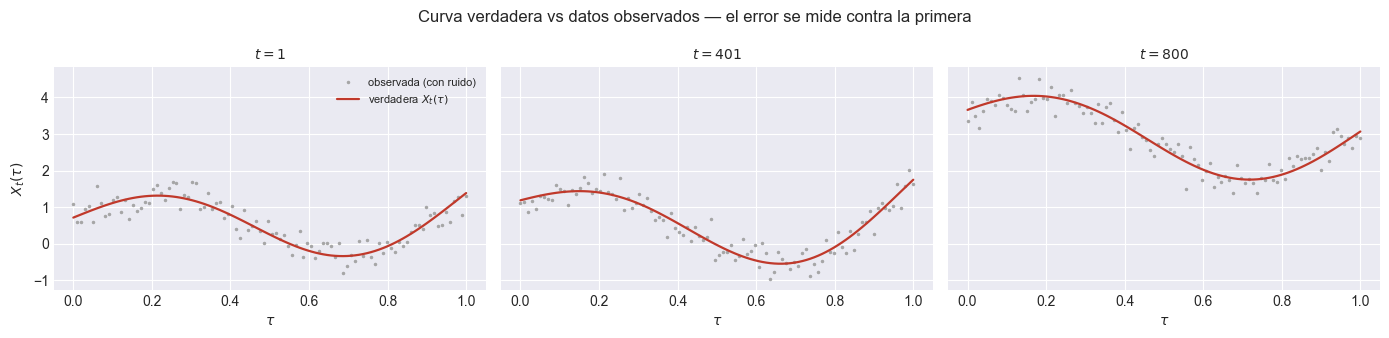

In [10]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
replicar_figura("04_curva_vs_datos.png", PATHS_POR_M, fig=fig)
plt.show()

### 2.6 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [11]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 3 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 3 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 3 directorios)


### 2.7 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [12]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 560]      → (560, 100)
prueba        : t ∈ [561, 800]  → (240, 100)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,82.2195%,0.552989,0.834772,0.325611
1,3,2,85.2003%,0.505743,0.679348,0.276640
2,4,2,95.6156%,0.276672,0.363101,0.083670
3,5,2,96.3116%,0.253973,0.330153,0.071877
4,6,2,96.5422%,0.245914,0.307861,0.068825
5,7,2,96.6417%,0.242361,0.310357,0.068291
6,8,2,96.7078%,0.239960,0.304227,0.068409
7,9,2,96.7620%,0.237968,0.304104,0.068769
8,10,2,96.8049%,0.236370,0.300746,0.069375
9,11,2,96.8430%,0.234962,0.299170,0.070098



GCV mínimo → n_basis=6, order=4  (var retenida 96.6608%)


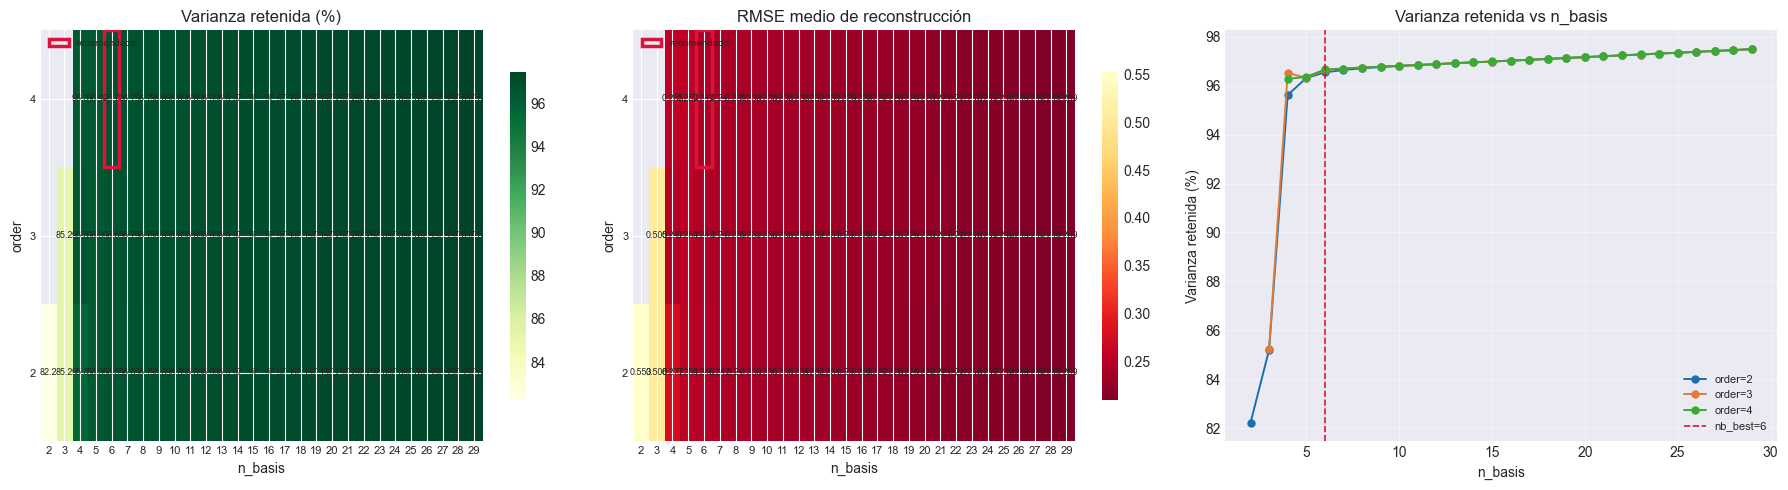

In [13]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=6, order=4
Sugerido GCV : n_basis=6, order=4   (coinciden)
THETA (800, 6)  (train=560, test=240)


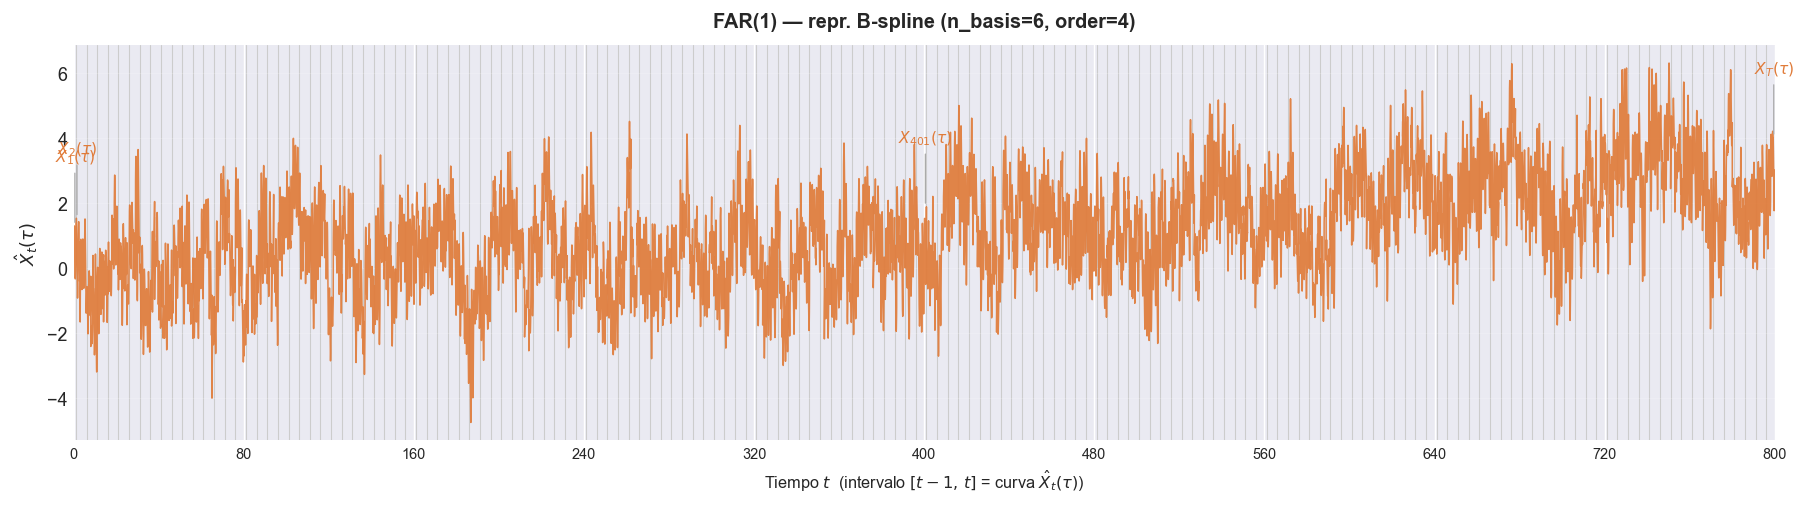

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 3 directorios)


In [14]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [15]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 6
  K                                  = 6
  n_ajuste                           = 560
  cond_W                             = 2.790e+01
  err_ortonormalidad_L2              = 2.331e-15
  err_ortonormalidad_gram            = 2.220e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 6.661e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.917e-16
  err_media_scores_rel               = 5.338e-15
  err_var_scores_vs_lambda           = 1.998e-15
  err_var_scores_vs_lambda_rel       = 1.803e-13
  err_correlacion_lag0               = 1.291e-13
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,1.4683e+00,86.0654%,86.0654%,+0.695
1,2,1.9997e-01,11.7213%,97.7867%,+0.240
2,3,3.3349e-02,1.9548%,99.7415%,+0.077
3,4,2.9861e-03,0.1750%,99.9165%,+0.019
4,5,8.2884e-04,0.0486%,99.9651%,-0.053
5,6,5.9541e-04,0.0349%,100.0000%,-0.076



K disponibles: 6   ·   sugerencia (var ≥ 95%): M = 2
  M=1: var. acum = 86.0654%  ·  sensibilidad
  M=2: var. acum = 97.7867%  ·  regla del 95 %
  M=3: var. acum = 99.7415%  ·  sensibilidad


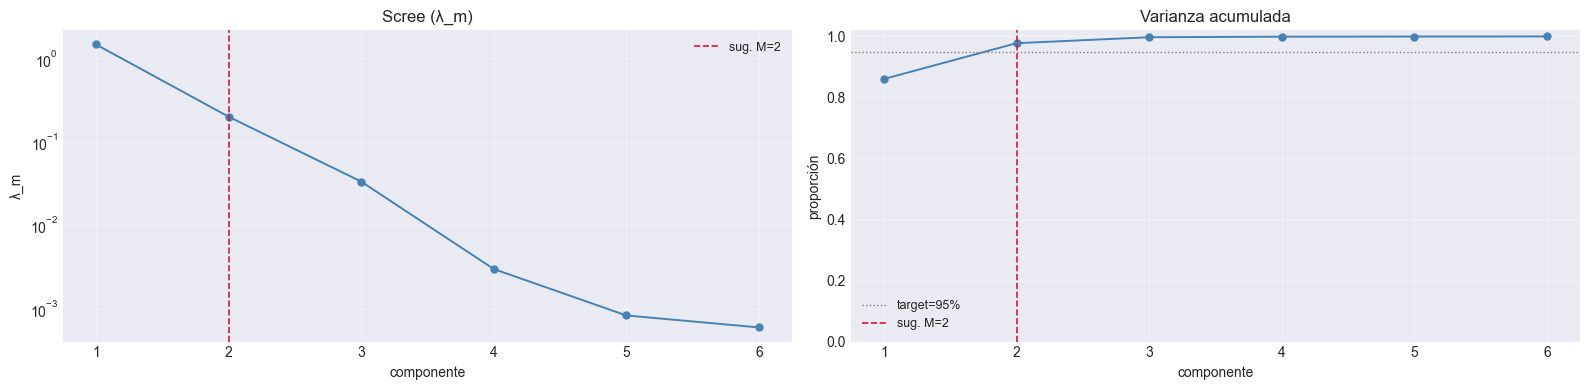

In [16]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido: no hay más de K componentes que retener.
# Con mu = sin(2 pi tau) el GCV eligió una base corta, de modo que los puntos
# altos del barrido caen en componentes que son en buena medida artefacto de
# esa base y no direcciones del proceso. Se advierte, no se oculta.
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

| Bloque | Qué hace |
|---|---|
| §4.1 | `set_M(M)` y scores; contraste con la regla del 95 % |
| §4.2 | estandarización (**sólo train**) y artefactos FPCA |
| §4.3 | diagnóstico de rezagos sobre el bloque de entrenamiento |
| §4.4 | orden AR y construcción de los datasets |
| §4.5 | hiperparámetros y `mcmc_config` — el contrato con MATLAB |
| §4.6 | `eval_config`, líneas base y `verificar_contrato` |

In [17]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    # M se declara en la celda [BARRIDO] de §1.1 porque forma parte del
    # EXPERIMENT_ID y las rutas se arman antes de llegar aquí. Aquí sólo se
    # consume y se contrasta con la regla del 95 % (M_SUGERIDO, de §3.3).
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Estandarización ------------------------------------------------
    # Se ajusta SÓLO con train y registra n_ajuste para que esa disciplina sea
    # auditable desde el artefacto y no una promesa del notebook. La ausencia
    # de fuga en el FPCA ya es propiedad de la clase (su fit vio sólo train);
    # aquí no se reajusta nada, sólo se trunca.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    SCORES_STD       = scores_standardizer.transform(SCORES)
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}")
    print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (~0)")
    print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (~0)")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi estandarizados"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    # Los rezagos del primer origen de prueba vienen del final del bloque de
    # entrenamiento: son observaciones pasadas disponibles en cada origen, de
    # modo que su uso es el condicionamiento de la predicción a h=1, no fuga.
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "standardized_zscore_ddof0",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparámetros y MCMC: el contrato con MATLAB -----------------
    # psbp_fd_iteracion.m lee estos valores del JSON y no los tiene escritos a
    # mano, incluida seed_base. Ojo con la doble acepción de M: dentro de
    # mcmc_config es el tamaño de la grilla de localización G* del
    # stick-breaking, NO el número de componentes FPCA; N es el truncamiento
    # del número de átomos.
    def _clasificar(nombre, k_modelo):
        return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
                else "cross_lag")

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        tipos = [_clasificar(nm, k) for nm in cov_names]
        vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "apij": vals[:, 0], "bpij": vals[:, 1],
            "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
        print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
        for j, nm in enumerate(cov_names):
            a, b = hp["apij"][j], hp["bpij"][j]
            marca = "  <" if _clasificar(nm, k) == "own_lag1" else ""
            print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
                  f"{a/(a+b):>7.3f}{marca}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "standardized_zscore_ddof0",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    # objetivo_evaluacion y modo_residuo se declaran aquí porque cambian el
    # significado de toda la evaluación y no deben quedar como una decisión
    # implícita del notebook _04. Son idénticos entre puntos del barrido, y
    # 31_04 lo exige con assert.
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "standardized_zscore_ddof0",
        # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
        #   curva_verdadera + modo_residuo "ninguno" => la banda cubre la curva
        #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau). Lo
        #   que queda fuera es truncamiento FPCA puro, sin el ruido de medición.
        "objetivo_evaluacion": "curva_verdadera",
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
        "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
        "metrics_curvas": ["MISE", "RMSE_funcional"],
        "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_true, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva VERDADERA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_names)),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

N_LAGS      : 1
MCMC_CONFIG : {'nsim': 2500, 'burn': 500, 'N': 35, 'M': 35}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (2500 - 500) x 2 = 4000

M = 1   ·   escenario_T_1_r01_m01
M(95 %) según la regla : 2   (K disponible = 6)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 86.0654%
[train] max|media xi| = 2.54e-16   (~ 0)
[test]  max|media xi| = 1.699
[test]  var xi / lambda = [0.971]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 1)
  [train] max|media| = 2.54e-17  (~0)
  [train] max|std-1| = 0.00e+00  (~0)
  [test]  media = [-1.404]
  [test]  std   = [0.984]

[functional] artefactos FPCA · cond_W = 2.790e+01


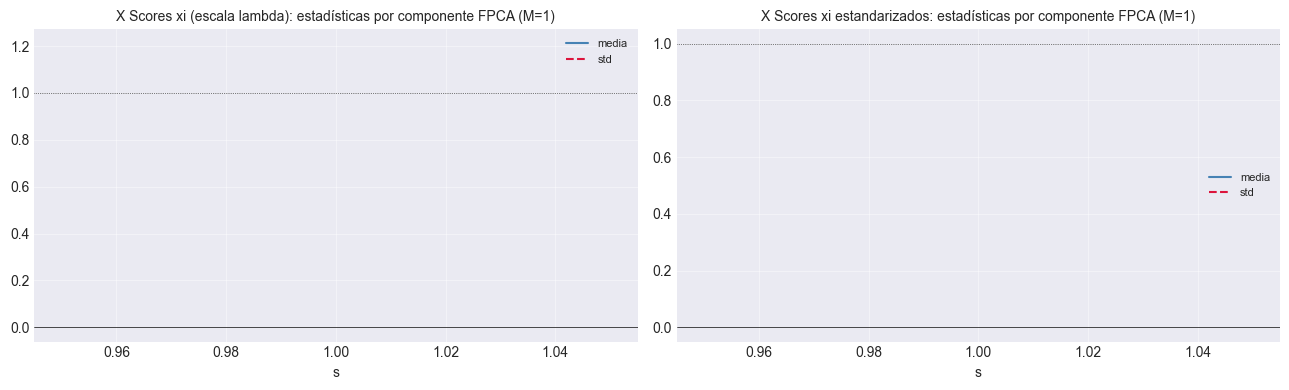

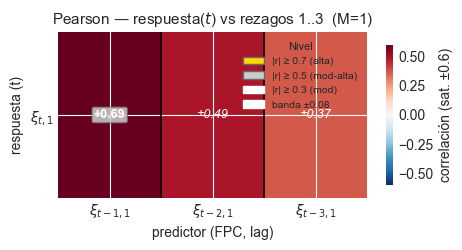

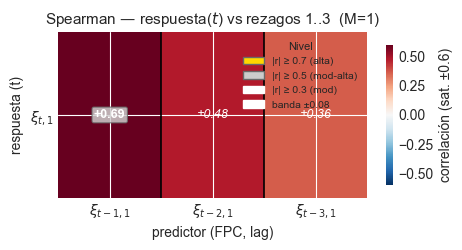

componentes : 1 -> índices [0]
N_LAGS      : 1   ·   p = 1 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (559, 2) · test (240, 2)

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_T_1_r01_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,240.0000,1.7143,1.7143,-2.0336,4.6218,2.1498
persistencia_lag1,240.0000,0.7556,0.7556,0.4106,1.1512,1.0729


contrato_ok = True   (M=1, K=6, T0=560, n_components=1)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_T_1_r01_m02
M(95 %) según la regla : 2   (K disponible = 6)
M de este punto        : 2   (coincide con la regla)
M = 2   var. explicada = 97.7867%
[train] max|media xi| = 2.52e-16   (~ 0)
[test]  max|media xi| = 1.699
[test]  var xi / lambda = [0.971 1.224]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 2)
  [train] max|media| = 3.01e-17  (~0)
  [train] max|std-1| = 7.77e-16  (~0)
  [test]  media = [-1.404  0.007]
  [test]  std   = [0.984 1.105]

[functional] artefactos FPCA · cond_W = 2.790e+01


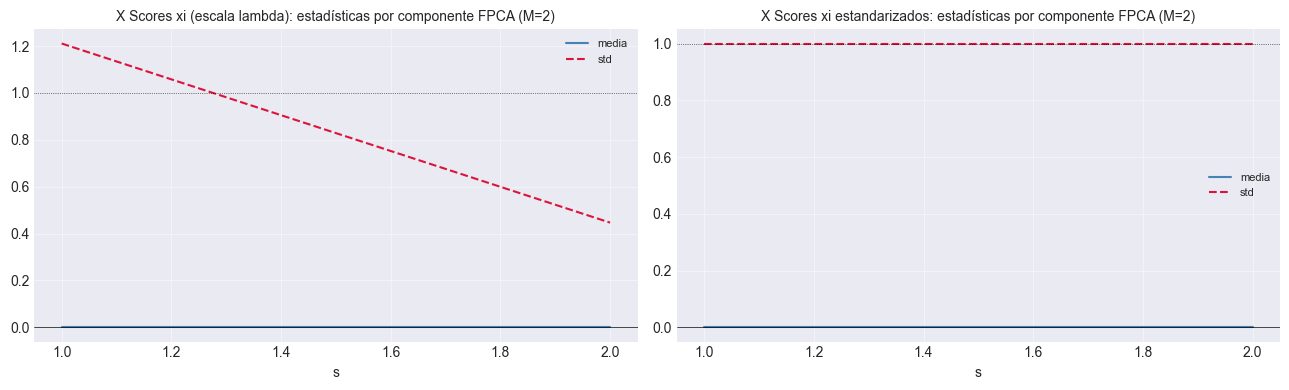

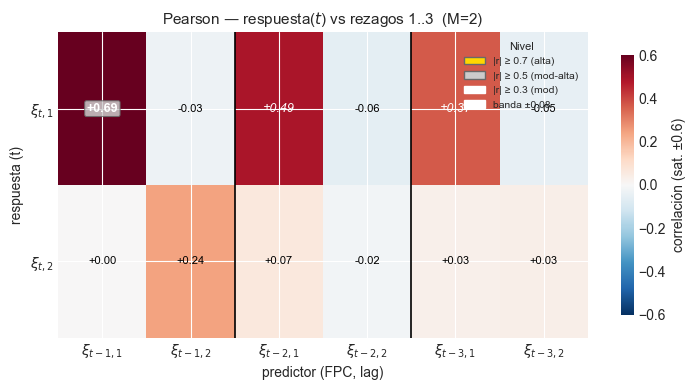

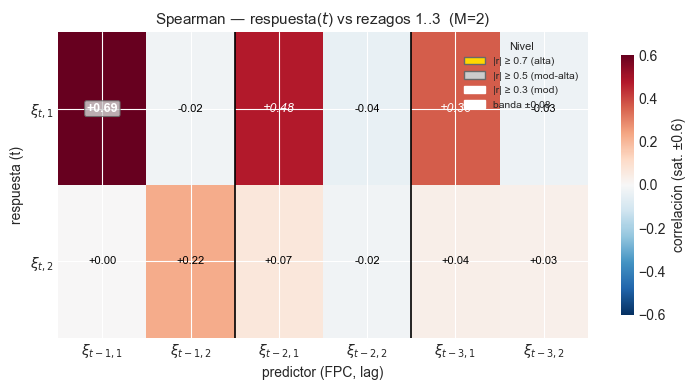

componentes : 2 -> índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (559, 3) · test (240, 3)
  fpc_2: train (559, 3) · test (240, 3)

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_2_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  <
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_T_1_r01_m02
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,240.0000,1.7143,1.1051,1.4097,-1.0168,4.6218,2.1498
persistencia_lag1,240.0000,0.7556,1.3802,1.0679,-0.0746,1.2889,1.1353


contrato_ok = True   (M=2, K=6, T0=560, n_components=2)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True

M = 3   ·   escenario_T_1_r01_m03
M(95 %) según la regla : 2   (K disponible = 6)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 99.7415%
[train] max|media xi| = 2.52e-16   (~ 0)
[test]  max|media xi| = 1.699
[test]  var xi / lambda = [0.971 1.224 1.001]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 3)
  [train] max|media| = 3.01e-17  (~0)
  [train] max|std-1| = 7.77e-16  (~0)
  [test]  media = [-1.404  0.007 -1.106]
  [test]  std   = [0.984 1.105 0.999]

[functional] artefactos FPCA · cond_W = 2.790e+01


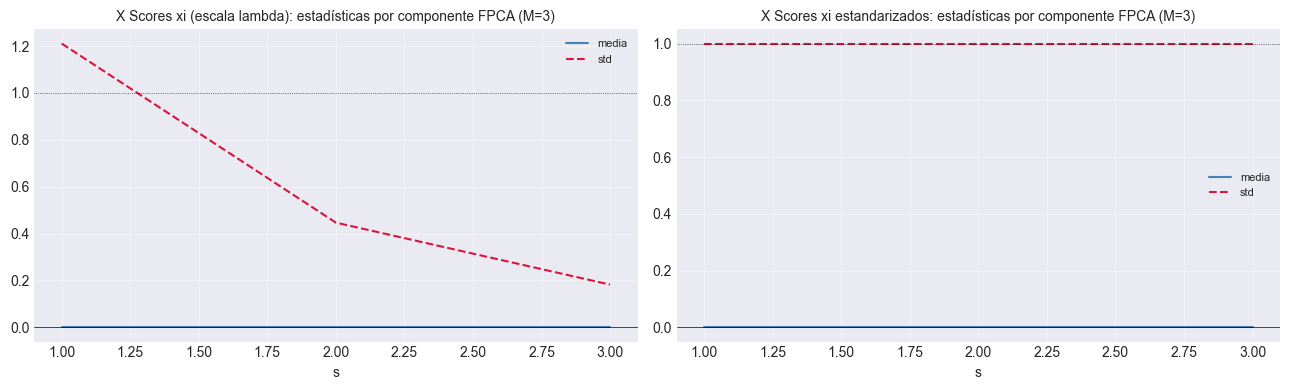

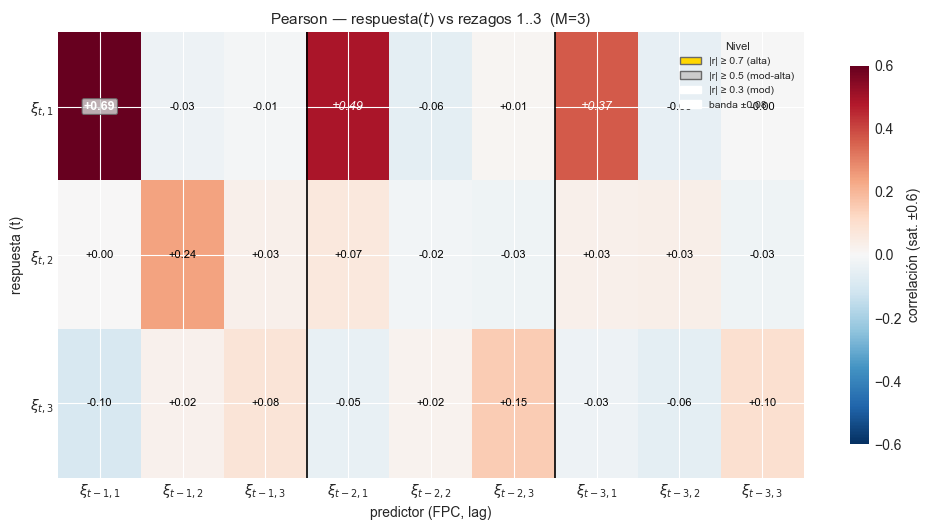

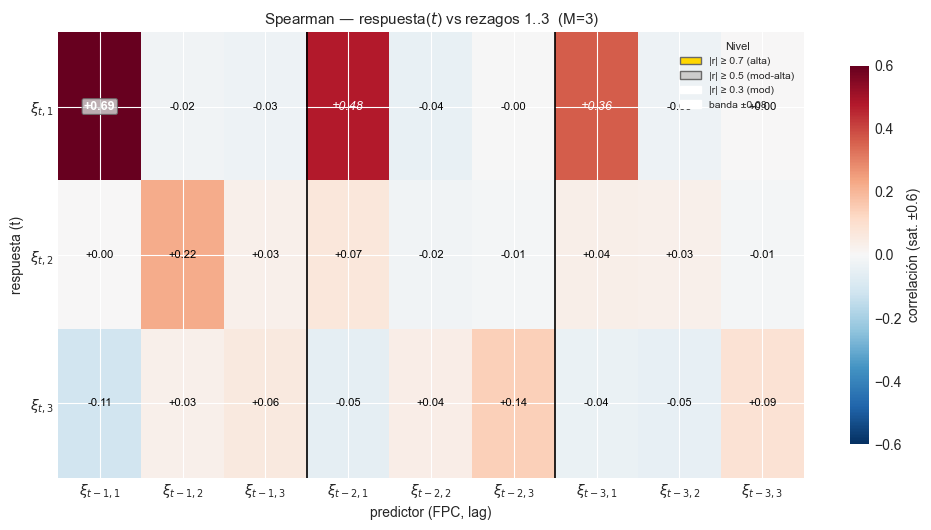

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (559, 4) · test (240, 4)
  fpc_2: train (559, 4) · test (240, 4)
  fpc_3: train (559, 4) · test (240, 4)

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo         

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,240.0000,1.7143,1.1051,1.4903,1.4366,-1.0857,4.6218,2.1498
persistencia_lag1,240.0000,0.7556,1.3802,1.3532,1.1630,-0.3275,1.2755,1.1294


contrato_ok = True   (M=3, K=6, T0=560, n_components=3)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True


In [18]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
N_LAGS      = 1
MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": 35, "M": 35}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

print(f"N_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [19]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{' '.join(str(m) for m in M_FPCA_LIST)}]  "
      f"(el mismo de 31_03, 31_04 y 31_05)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_T_1_r01_m01,86.0654%,6,False,1,1,True
2,escenario_T_1_r01_m02,97.7867%,6,True,2,2,True
3,escenario_T_1_r01_m03,99.7415%,6,False,3,3,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1 2 3]  (el mismo de 31_03, 31_04 y 31_05)
